# Imports

In [1]:
from Functions_lw_analysis import *

atms = ["EMPTATM","SMLSATM","SMLWATM","TUXUATM"]

# Datas and Output new snow emissivity

In [3]:
flux_npy(
        exp = "lavey",
        res = "30",
        n_cam = "100",
        uniforme = '00',
        atms = atms)

 24%|██████████                                | 24/100 [00:45<02:22,  1.87s/it]/home/barroisl/edstar/Simus/Functions_lw_analysis.py:256: RuntimeWarning: invalid value encountered in scalar divide
  self.Nbre_moyen_reflexion_exc = self.Nbre_reflexion/data_path[data_path[:,2] != 0].shape[0]
100%|█████████████████████████████████████████| 100/100 [03:03<00:00,  1.83s/it]


In [5]:
flux_npy(
        exp = "lavey",
        res = "30",
        n_cam = "100",
        uniforme = '65',
        atms = atms)

100%|█████████████████████████████████████████| 100/100 [02:56<00:00,  1.77s/it]


In [2]:
dire = "/home/barroisl/Transect_MC_auto/"
fic_topo_param = dire + "camera_tgt/topo_polygon_lavey_30_100.txt"
ds = xr.open_dataset("/home/barroisl/Transect_MC_auto/topographie/lavey_topo_params_30.nc")
lapse_rates = ["00","65"]
lrs = [0,-6.5e-3]
    
for j,lr in enumerate(lapse_rates):
        
        ds['ts'] = (['y','x'], altit_T(dem = ds['zs'].values,
                                      T0 = 273,
                                      z0 = 1300,
                                      lapse_rate = lrs[j]))
                    
        print(ds['ts'].values)
        
        for i,atm in enumerate(atms):
            
            dir_data = dire + f"Data/lavey_30_100_atms_{lr}_emis/{atm}/"
            fic_cam_tgt = dire + "camera_tgt/polygon_lavey_30_100.txt"
            fic_res = dire + f"Output/lavey_30_100_atms_{lr}_emis/topo_flux_{atm}.txt"

            from_transect_to_pdt(
                fic_topo_param,
                dir_data,
                fic_cam_tgt,
                fic_res,
                ds = ds)

[[273 273 273 ... 273 273 273]
 [273 273 273 ... 273 273 273]
 [273 273 273 ... 273 273 273]
 ...
 [273 273 273 ... 273 273 273]
 [273 273 273 ... 273 273 273]
 [273 273 273 ... 273 273 273]]


 24%|██████████                                | 24/100 [00:47<02:27,  1.95s/it]/home/barroisl/edstar/Simus/Functions_lw_analysis.py:256: RuntimeWarning: invalid value encountered in scalar divide
  self.Nbre_moyen_reflexion_exc = self.Nbre_reflexion/data_path[data_path[:,2] != 0].shape[0]
100%|█████████████████████████████████████████| 100/100 [03:36<00:00,  2.17s/it]


[[271.5895 271.5115 271.492  ... 268.372  268.3655 268.359 ]
 [271.453  271.375  271.4205 ... 268.3655 268.359  268.3525]
 [271.3035 271.3165 271.375  ... 268.346  268.346  268.346 ]
 ...
 [272.675  272.662  272.649  ... 264.303  264.2965 264.277 ]
 [272.662  272.6425 272.636  ... 264.3875 264.368  264.368 ]
 [272.6425 272.636  272.623  ... 264.459  264.446  264.459 ]]


100%|█████████████████████████████████████████| 100/100 [03:24<00:00,  2.04s/it]


# Plotting symbolique test for new emissivity of snow

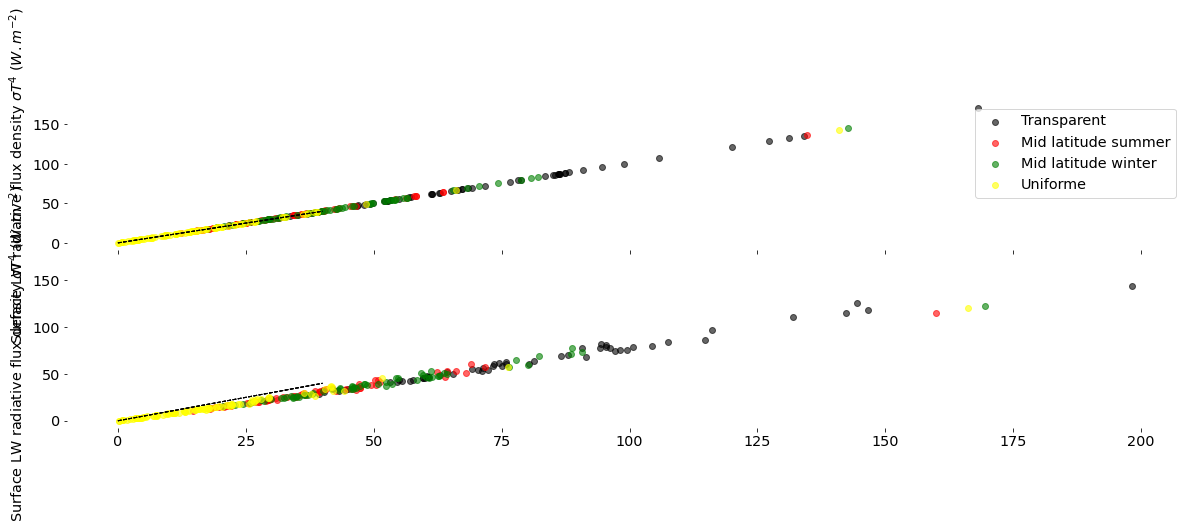

In [8]:
dire = "/home/barroisl/Transect_MC_auto/"
lapse_rates = ["00","65"]
lrs = [0,-6.5e-3]
fig,axs = plt.subplots(sharex=True,nrows = 2, ncols = 1, figsize = (20,6))

for i,atm in enumerate(atms): 
    for j, lr in enumerate(lapse_rates):
        
        fic_res = dire + f"Output/lavey_30_100_atms_{lr}_emis/topo_flux_{atm}.txt"
        topo_flux = np.loadtxt(fic_res)

        plot_MC_symoblique_test(
            ax = axs[j],
            atm = atm,
            topo_flux = topo_flux,
            dict_map = dict_map,
            plot_reg = False,
            alpha = 0.6,
            epsilon_surf = 0.98)
    axs[0].legend()

#plt.savefig(dire + "Output/symbolique_hist.jpg")